# Implementacion

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Funciones

In [ ]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

# Cargado de datos

In [ ]:
data_url = 'https://docs.google.com/spreadsheets/d/1_KCCMLmD6jYINRbLJwud-moSgEkevpdJtc8VIbZuAVM/export?format=csv'

In [ ]:
df = pd.read_csv(data_url)

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

# Analisis exploratorio de datos

In [ ]:
Summary(df, 'df')

Hoja: df

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,4424,37,0,0



Encabezado:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Las columnas de Curriculum units(grade) en ambos semestres no tienen un redondeo universal en los datos por lo que se realizara ese redondeo a 2 decimas debido a que son notas

In [ ]:
df['Curricular units 1st sem (grade)']=df['Curricular units 1st sem (grade)'].round(2)
df['Curricular units 2nd sem (grade)']=df['Curricular units 2nd sem (grade)'].round(2)

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.00,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.67,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.00,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.40,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.00,0,13.9,-0.3,0.79,Graduate


debemos tomar en cuenta que algunas de las variables numericas en realidad tienen categorias asignadas a cada uno de sus datos. Por lo que debemos tener cuidado al tratarlos

Se realizara primero el analisis de las variables numericas que no tienen categorias asignadas a ellas

In [ ]:
numericas=['Previous qualification (grade)','Admission grade','Age at enrollment','Curricular units 1st sem (approved)','Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)','Curricular units 1st sem (evaluations)','Curricular units 1st sem (without evaluations)',
'Curricular units 2nd sem (approved)','Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)','Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (without evaluations)','GDP']

In [ ]:
df[numericas].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (without evaluations),GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,23.265145,4.706600,0.709991,6.270570,8.299051,0.137658,4.435805,0.541817,6.232143,8.063291,0.150316,0.001969
std,13.188332,14.482001,7.587816,3.094238,2.360507,2.480178,4.179106,0.690880,3.014764,1.918546,2.195951,3.947951,0.753774,2.269935
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.060000
25%,125.000000,117.900000,19.000000,3.000000,0.000000,5.000000,6.000000,0.000000,2.000000,0.000000,5.000000,6.000000,0.000000,-1.700000
50%,133.100000,126.100000,20.000000,5.000000,0.000000,6.000000,8.000000,0.000000,5.000000,0.000000,6.000000,8.000000,0.000000,0.320000
75%,140.000000,134.800000,25.000000,6.000000,0.000000,7.000000,10.000000,0.000000,6.000000,0.000000,7.000000,10.000000,0.000000,1.790000
max,190.000000,190.000000,70.000000,26.000000,20.000000,26.000000,45.000000,12.000000,20.000000,19.000000,23.000000,33.000000,12.000000,3.510000


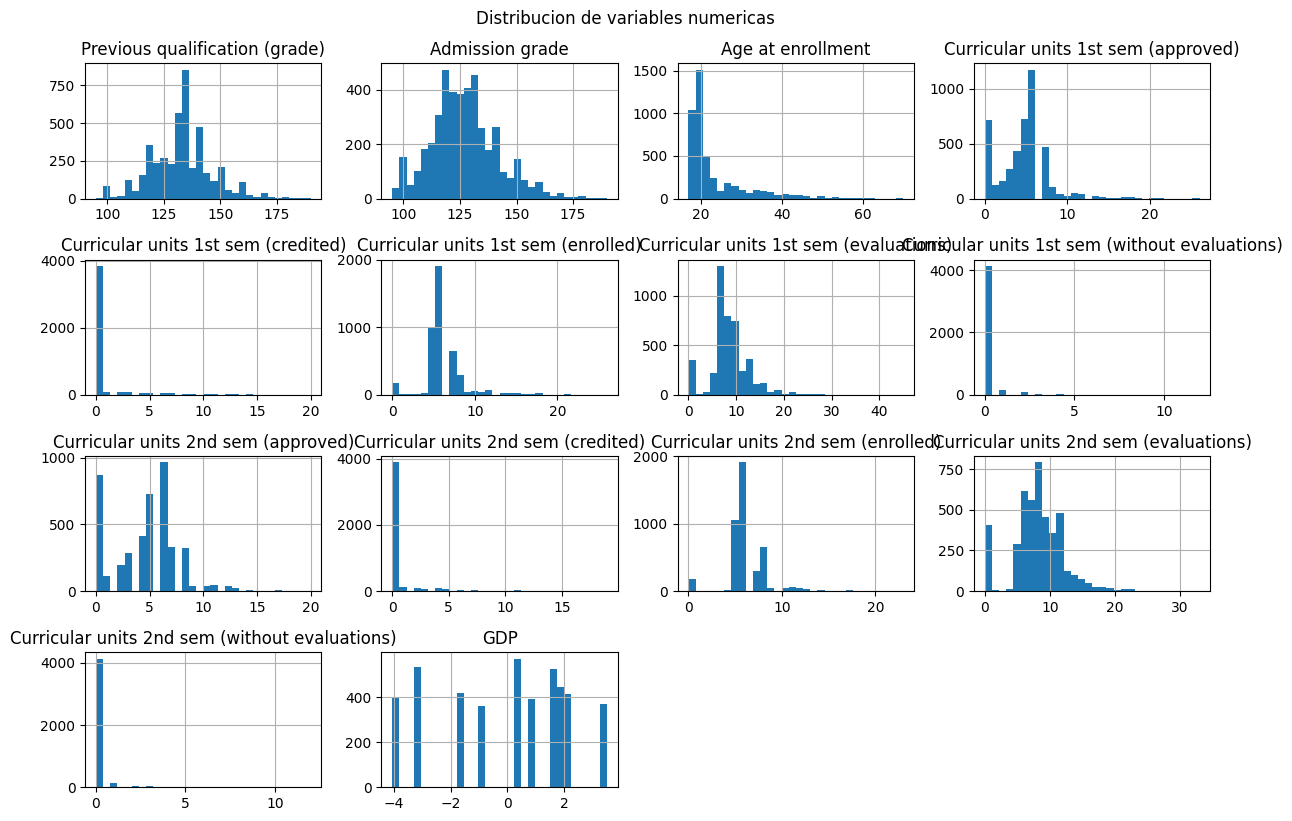

In [ ]:
df[numericas].hist(bins=30,figsize=(12,8))
plt.tight_layout()
plt.suptitle('Distribucion de variables numericas',y=1.02)
plt.show()

añadimos tambien las que representan porcentajes

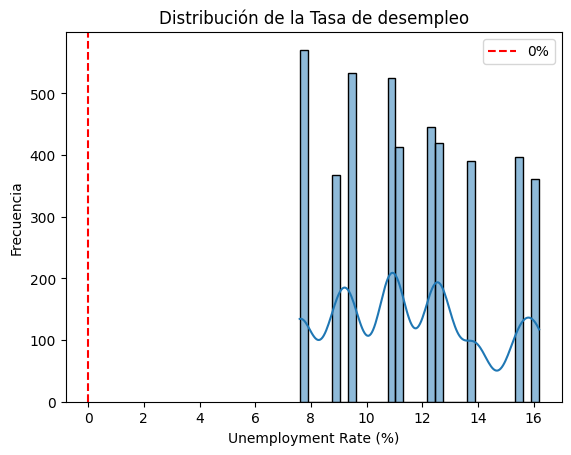

In [ ]:
sns.histplot(data=df, x='Unemployment rate', bins=30, kde=True)
plt.title('Distribución de la Tasa de desempleo')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='0%')
plt.legend()
plt.show()

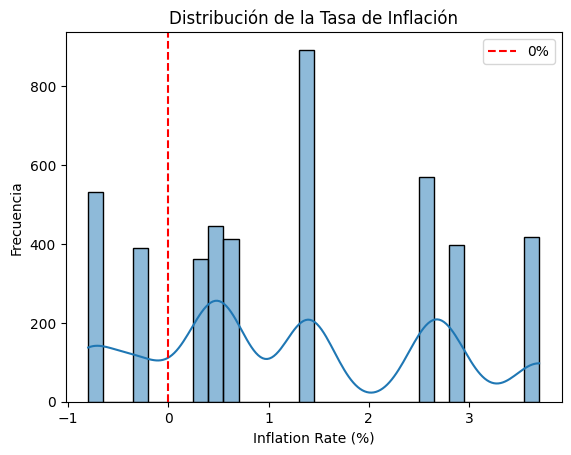

In [ ]:
sns.histplot(data=df, x='Inflation rate', bins=30, kde=True)
plt.title('Distribución de la Tasa de Inflación')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='0%')
plt.legend()
plt.show()

realizamos boxplots para determinar la presencia de outliers en las variables numericas

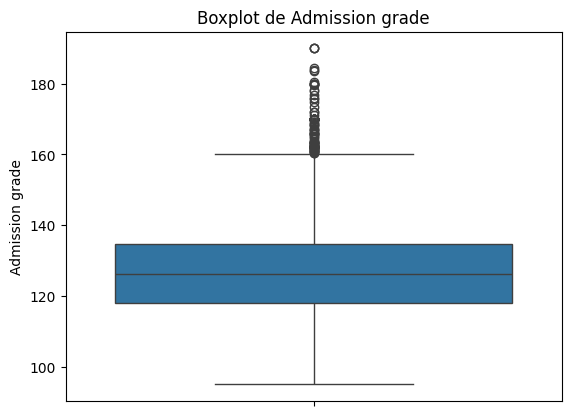

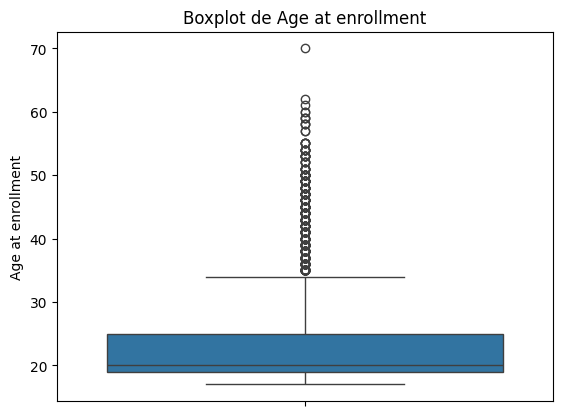

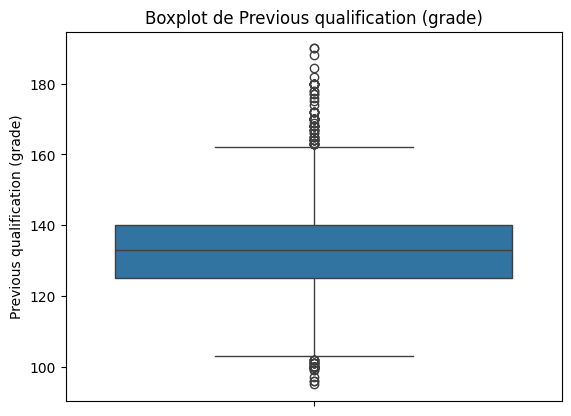

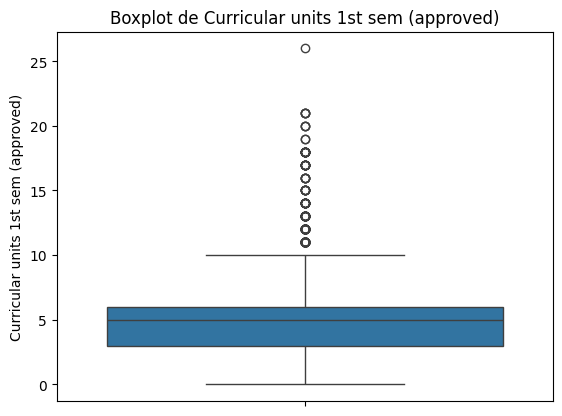

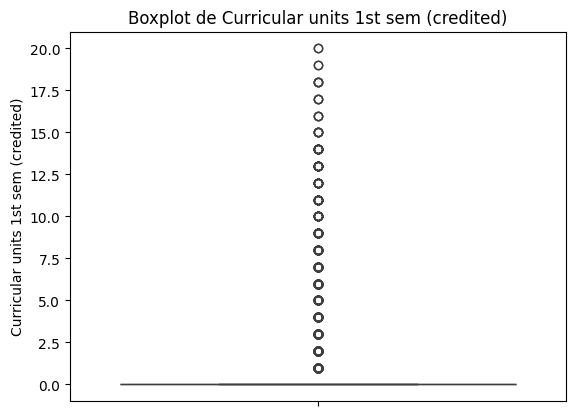

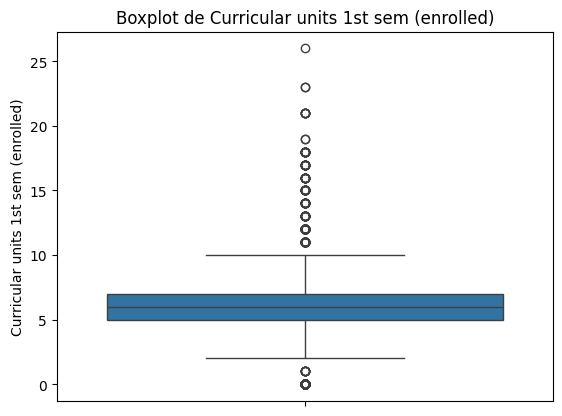

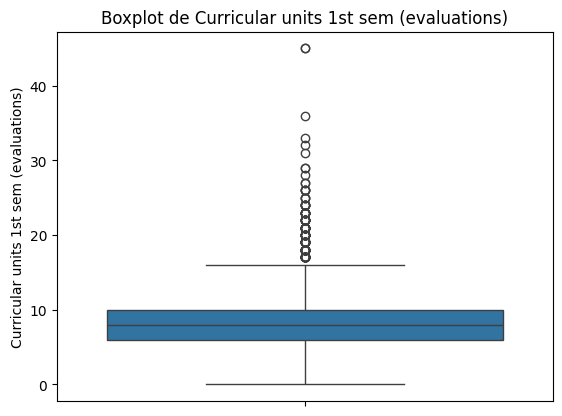

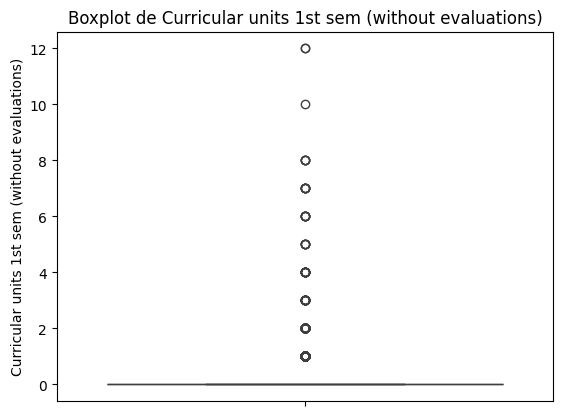

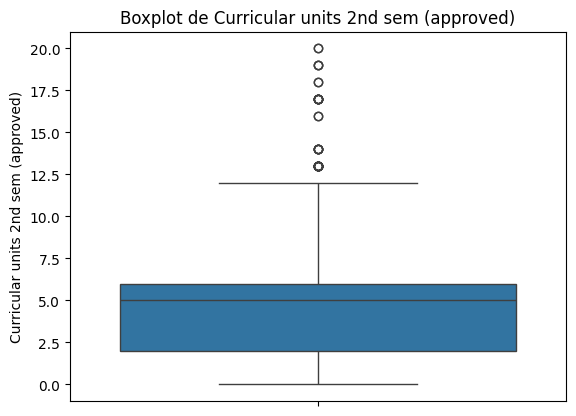

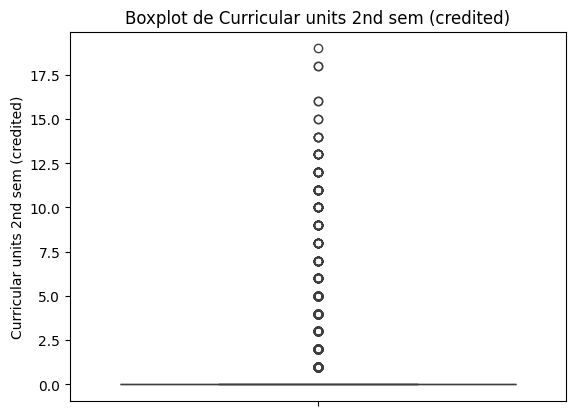

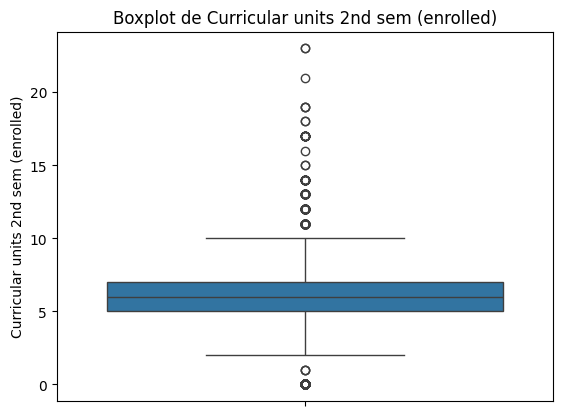

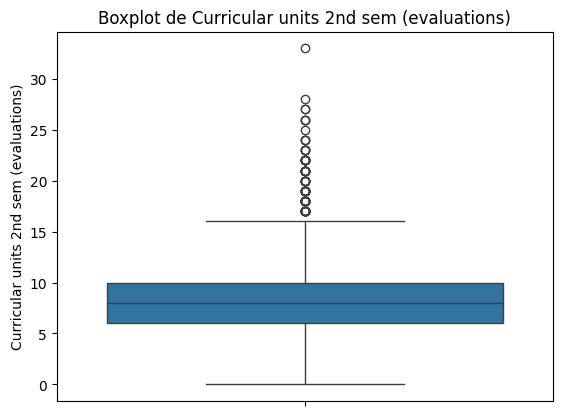

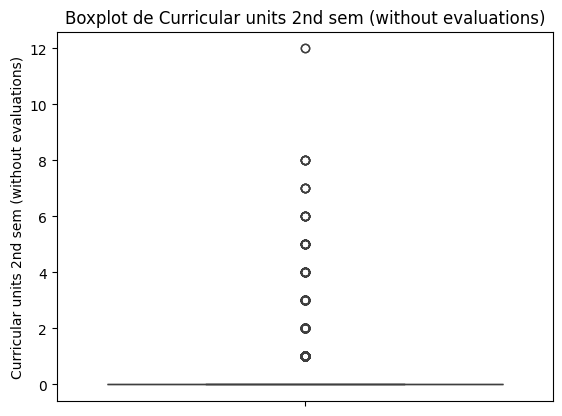

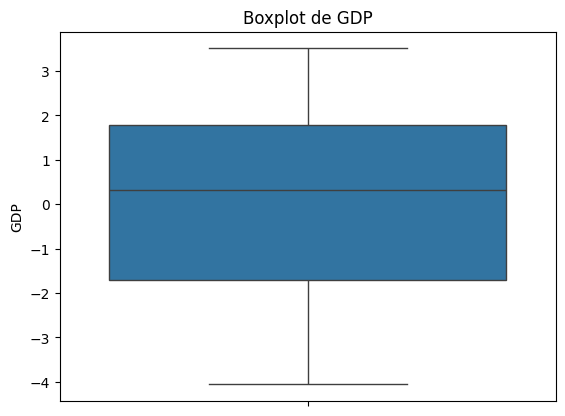

In [ ]:
for numerica in numericas:
  sns.boxplot(data=df,y=numerica)
  plt.title(f'Boxplot de {numerica}')
  plt.show()

reducimos los outliers mediante el rango intercuartilico

In [ ]:
df_copy=df.copy()

In [ ]:
for col in numericas:
  Q1=df_copy[col].quantile(0.25)
  Q3=df_copy[col].quantile(0.75)
  IQR=Q3-Q1
  filtro = (df_copy[col] >= Q1 - 1.5 * IQR) & (df_copy[col] <= Q3 + 1.5 * IQR)
  df_copy = df_copy[filtro]

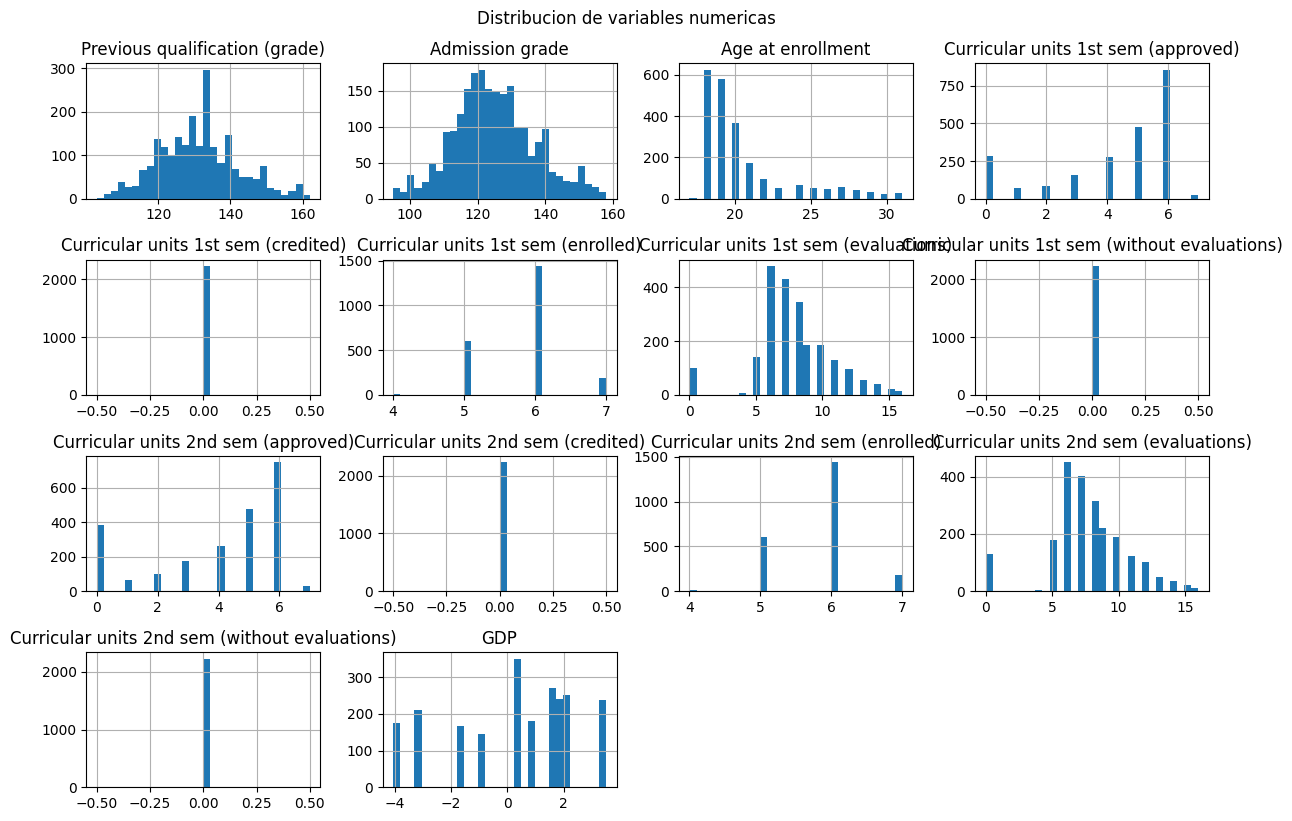

In [ ]:
df_copy[numericas].hist(bins=30,figsize=(12,8))
plt.tight_layout()
plt.suptitle('Distribucion de variables numericas',y=1.02)
plt.show()

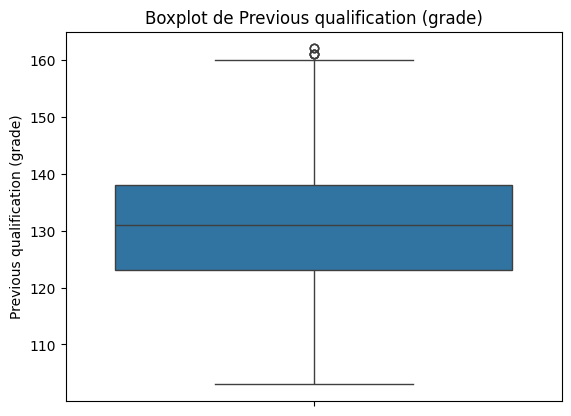

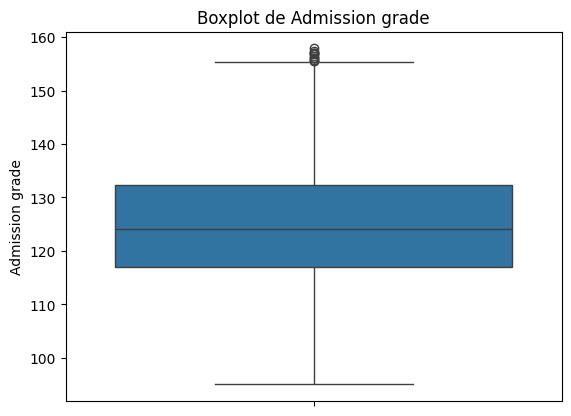

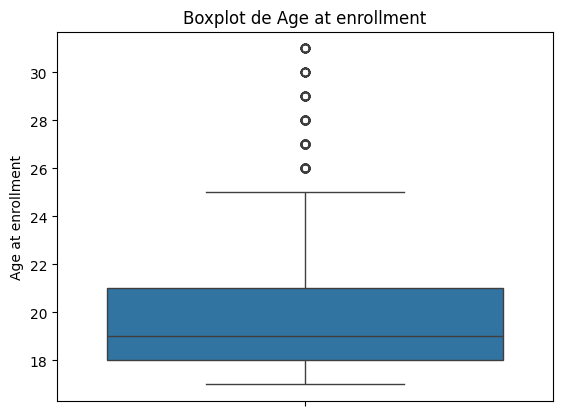

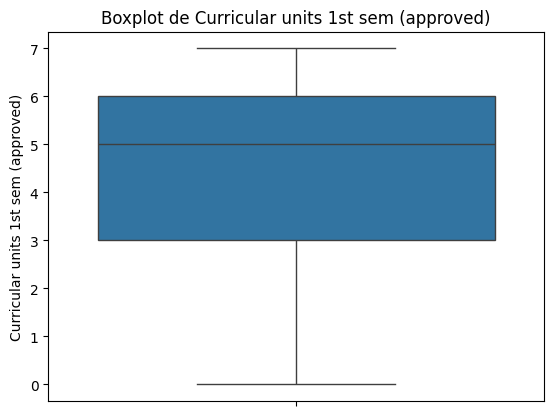

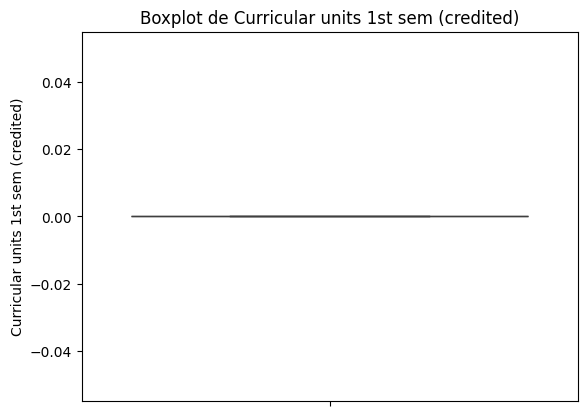

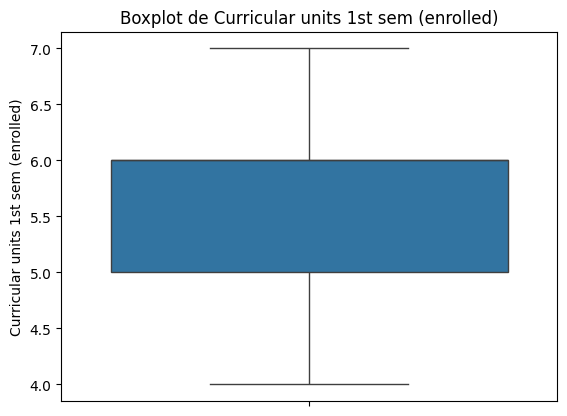

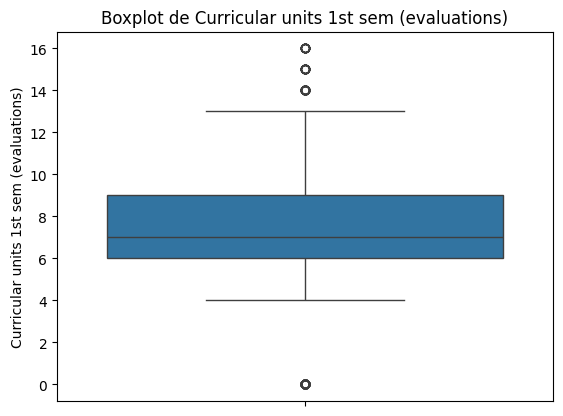

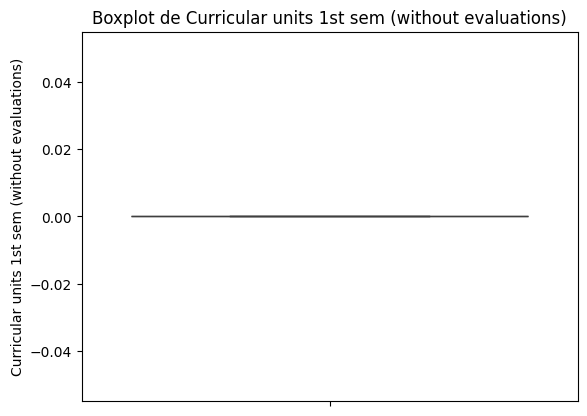

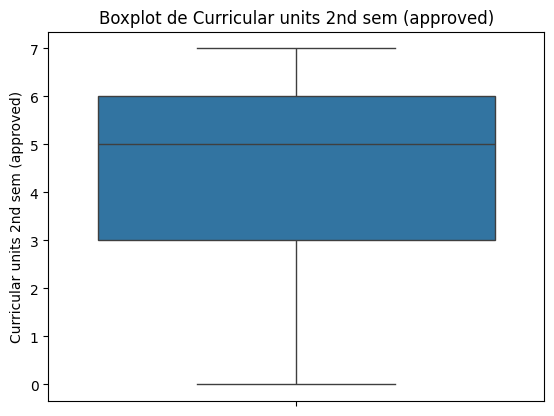

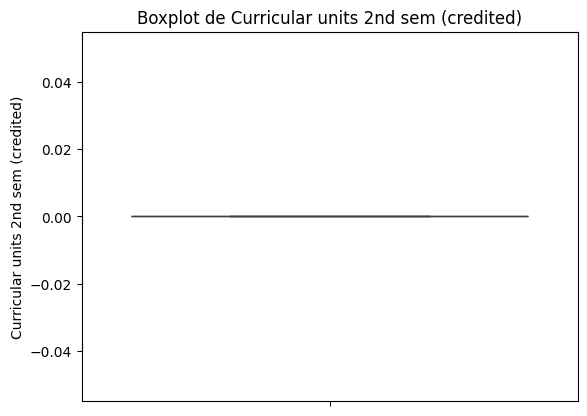

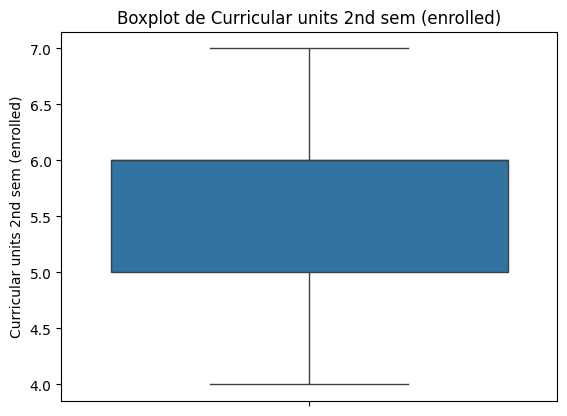

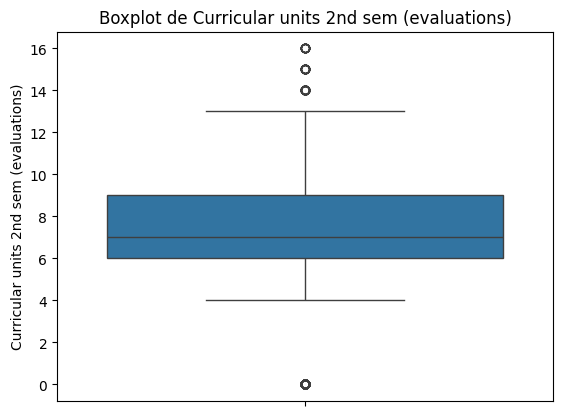

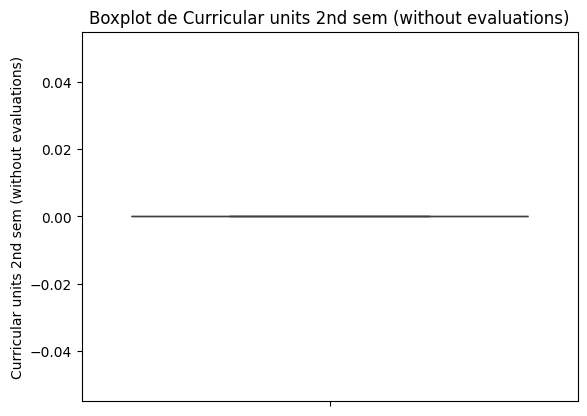

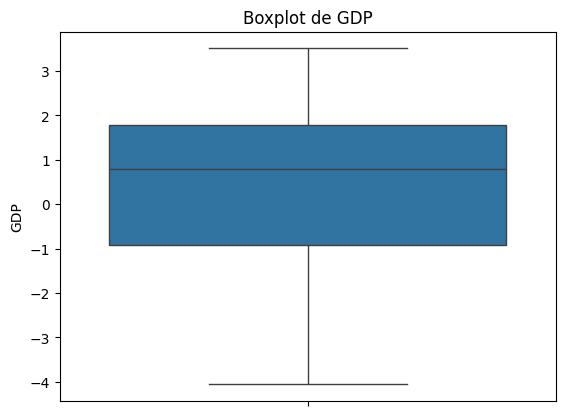

In [ ]:
for numerica in numericas:
  sns.boxplot(data=df_copy,y=numerica)
  plt.title(f'Boxplot de {numerica}')
  plt.show()

codificamos las variables que tienen categorias asociadas a ellas y las variables categoricas que existen en el dataframe

Variables binarias

In [ ]:
binarias=['Daytime/evening attendance\t','Displaced','Educational special needs','Debtor','Tuition fees up to date','Gender','Scholarship holder','International']
for col in binarias:
  df_copy[col]=df_copy[col].map({'yes': 1, 'no': 0, 'male': 1,'female': 0,'daytime': 1, 'evening': 0})

Variables nominales(con pocas categorias)

In [ ]:
df_copy['Marital status'].value_counts(normalize=True)

,proportion
Marital status,
1,0.969072
2,0.021515
4,0.006275
5,0.002241
3,0.000448
6,0.000448


In [ ]:
nominal_short=['Marital Status','Course','','Target']